In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv('placement.csv')

In [7]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'package(LPA)')

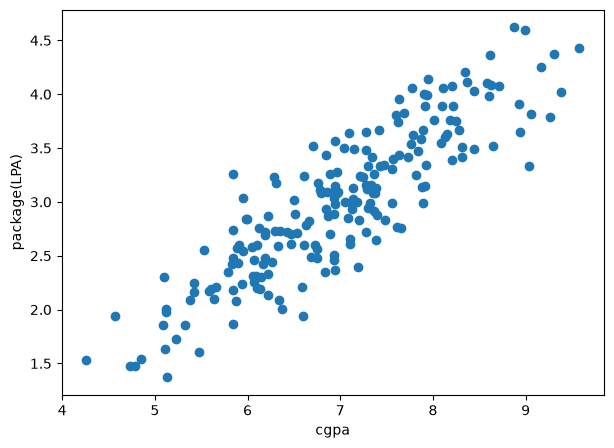

In [8]:
plt.figure(figsize=(7,5))
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('cgpa')
plt.ylabel('package(LPA)')

In [9]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,train_size=0.2,random_state=2)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
model=LinearRegression()

In [14]:
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.52]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.6008
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [15]:
model.predict(X_test.iloc[0].values.reshape(1,1))

c:\Users\Mubashar Ali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.88344381])

In [16]:
m=model.coef_
b=model.intercept_

In [17]:
print(m," ",b)

[0.52263476]   -0.6007624066050323


In [20]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [22]:
y_predict=model.predict(X_test)

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61, 3.13, 3.91, 2.25, 2.3 ,
       4.06, 3.18, 2.7 , 2.49, 3.15, 2.99, 4.08, 4.14, 2.6 , 2.44, 2.71,
       2.72, 1.63, 2.31, 2.51, 3.5 , 2.24, 2.58, 2.42, 2.54, 4.37, 2.17,
       3.14, 2.19, 3.54, 1.54, 2.72, 3.98, 2.46, 3.  , 1.98, 2.65, 3.75,
       3.67, 2.93, 3.08, 2.21, 2.84, 3.76, 3.03, 2.09, 3.26, 2.16, 2.7 ,
       3.83, 2.88, 3.16, 3.04, 3.13, 3.04, 4.6 , 3.26, 2.85, 2.09, 3.31,
       3.89, 1.87, 3.11, 2.4 , 3.48, 3.08, 2.76, 2.93, 3.39, 2.35, 3.08,
       2.14, 3.24, 1.73, 3.24, 3.44, 2.69, 3.33, 2.42, 2.57, 3.55, 2.66,
       1.53, 2.98, 2.84, 3.52, 3.16, 3.82, 2.6 , 1.61, 2.2 , 2.99, 3.12,
       2.74, 2.83, 2.77, 2.35, 2.19, 3.42, 4.02, 3.89, 3.15, 3.99, 3.42,
       3.08, 2.46, 2.61, 3.49, 3.76, 2.82, 4.03, 2.

In [24]:
print("MAE:",mean_absolute_error(Y_test,y_predict))

MAE: 0.2630894141056844


In [25]:
print('MSE:',mean_squared_error(Y_test,y_predict))

MSE: 0.10741989339162403


In [26]:
print('RMSE:',np.sqrt(mean_squared_error(Y_test,y_predict)))

RMSE: 0.32774974201610596


In [27]:
print('r2_score:',r2_score(Y_test,y_predict))

r2_score: 0.7693171377086014


In [31]:
r2_score=r2_score(Y_test,y_predict)
print('R2_score:',r2_score)

R2_score: 0.7693171377086014


In [32]:
adjust_r2=1-(1-r2_score)*(40-1)/(40-1-1)
print("Adjusted R2 score:",adjust_r2)

Adjusted R2 score: 0.7632465360693541
